In [1]:
# Enable GPU in Kaggle settings before running this code

import requests
import zipfile
import os

# Step 1: Define URL and file name
url = "https://data.mendeley.com/public-files/datasets/2h76672znt/files/9031138a-b812-433e-a704-8acb1707936e/file_downloaded"
dataset_zip = "isolated_words_per_user.zip"

# Step 2: Download the dataset
response = requests.get(url, stream=True)
with open(dataset_zip, "wb") as file:
    for chunk in response.iter_content(chunk_size=1024):
        file.write(chunk)
print(f"Downloaded {dataset_zip}")

# Step 3: Extract the dataset
with zipfile.ZipFile(dataset_zip, 'r') as zip_ref:
    zip_ref.extractall("./AHAWP_dataset")
print("Dataset extracted to './AHAWP_dataset'")

# Verify extracted files
print("Extracted files:", os.listdir("./AHAWP_dataset"))

Downloaded isolated_words_per_user.zip
Dataset extracted to './AHAWP_dataset'
Extracted files: ['isolated_words_per_user']


In [2]:
import os
import shutil
from sklearn.model_selection import train_test_split

# Define dataset paths
dataset_path = "./AHAWP_dataset/isolated_words_per_user"  
train_path = "./isolated_words_train"
test_path = "./isolated_words_test"

# Check if dataset path exists
if not os.path.exists(dataset_path):
    print(f"Dataset path not found: {dataset_path}")
    print("Please verify the path and update it in the script.")
else:
    print(f"Dataset path found: {dataset_path}")

    # Create directories for training and testing data
    os.makedirs(train_path, exist_ok=True)
    os.makedirs(test_path, exist_ok=True)

    # Get a list of all users
    users = [d for d in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, d))]
    print(f"Total users found: {len(users)}")

    # Process each user's data
    for user in users:
        user_path = os.path.join(dataset_path, user)
        user_images = [
            os.path.join(user_path, img) for img in os.listdir(user_path) if os.path.isfile(os.path.join(user_path, img))
        ]

        # Split images for this user into training and testing sets
        train_images, test_images = train_test_split(user_images, test_size=0.3, random_state=42)

        # Create user subdirectories in training and testing folders
        user_train_path = os.path.join(train_path, user)
        user_test_path = os.path.join(test_path, user)
        os.makedirs(user_train_path, exist_ok=True)
        os.makedirs(user_test_path, exist_ok=True)

        # Copy images to respective directories
        for img in train_images:
            shutil.copy(img, user_train_path)
        for img in test_images:
            shutil.copy(img, user_test_path)

        print(f"User {user}: {len(train_images)} training images, {len(test_images)} testing images.")

    print("Dataset successfully split into training and testing sets.")

Dataset path found: ./AHAWP_dataset/isolated_words_per_user
Total users found: 82
User user036: 70 training images, 30 testing images.
User user040: 70 training images, 30 testing images.
User user002: 70 training images, 30 testing images.
User user052: 70 training images, 30 testing images.
User user004: 70 training images, 30 testing images.
User user081: 70 training images, 30 testing images.
User user006: 70 training images, 30 testing images.
User user053: 70 training images, 30 testing images.
User user071: 70 training images, 30 testing images.
User user077: 70 training images, 30 testing images.
User user069: 70 training images, 30 testing images.
User user063: 70 training images, 30 testing images.
User user030: 70 training images, 30 testing images.
User user013: 70 training images, 30 testing images.
User user068: 70 training images, 30 testing images.
User user014: 70 training images, 30 testing images.
User user044: 70 training images, 30 testing images.
User user031: 70 

**Task1:**

*Model1:*

Num GPUs Available:  2
Loading training data...
Training data loaded: 5700 images, 82 classes.
Loading testing data...
Testing data loaded: 2444 images.
Training the model...
Epoch 1/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.0114 - loss: 4.4218
Epoch 1: Training Accuracy = 1.02%, Training Loss = 4.4116, Validation Accuracy = 1.68%, Validation Loss = 4.4025
179/179 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - accuracy: 0.0114 - loss: 4.4217 - val_accuracy: 0.0168 - val_loss: 4.4025
Epoch 2/50
176/179 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0177 - loss: 4.3680
Epoch 2: Training Accuracy = 2.16%, Training Loss = 4.3050, Validation Accuracy = 6.22%, Validation Loss = 4.0493
179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.0177 - loss: 4.3666 - val_accuracy: 0.0622 - val_loss: 4.0493
Epoch 3/50
168/179 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.0487 - loss: 4.0169
Epoch 3: Training Accuracy = 5.68%, Training Loss = 3.9098, Validation Accuracy = 11.46%, Validation Lo

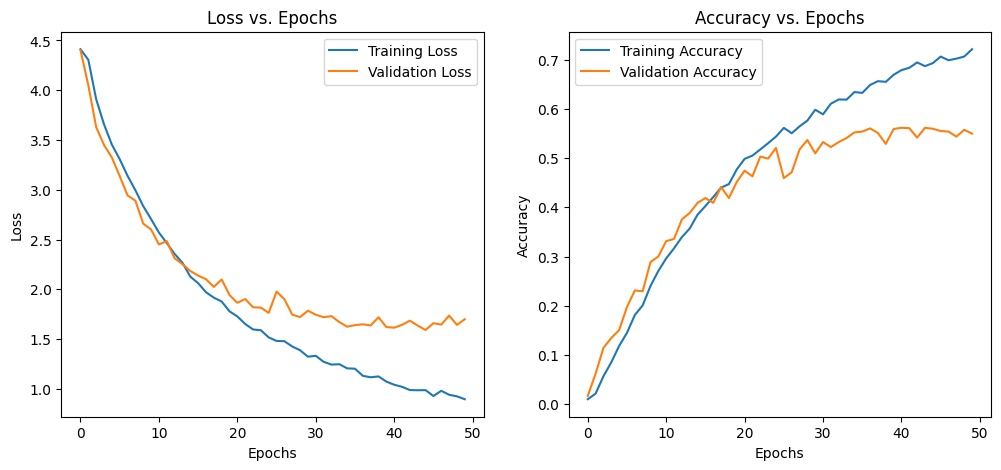

In [74]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Verify GPU availability
print("Num GPUs Available: ", len(tf.config.experimental.list_physical_devices('GPU')))

# Step 1: Load and preprocess the entire dataset
def load_dataset(dataset_path, img_size=(64, 64)):
    images, labels = [], []
    class_names = sorted(os.listdir(dataset_path))  # Each folder is a class
    class_map = {name: idx for idx, name in enumerate(class_names)}  # Map class names to indices

    for class_name in class_names:
        class_path = os.path.join(dataset_path, class_name)
        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)
            img = tf.keras.preprocessing.image.load_img(img_path, color_mode="grayscale", target_size=img_size)
            img_array = tf.keras.preprocessing.image.img_to_array(img) / 255.0  # Normalize to [0, 1]
            images.append(img_array)
            labels.append(class_map[class_name])

    return np.array(images), to_categorical(labels), class_names

# Load training and testing datasets
train_path = "./isolated_words_train"  
test_path = "./isolated_words_test"  
img_size = (64, 64)

print("Loading training data...")
X_train, y_train, class_names = load_dataset(train_path, img_size)
print(f"Training data loaded: {X_train.shape[0]} images, {len(class_names)} classes.")

print("Loading testing data...")
X_test, y_test, _ = load_dataset(test_path, img_size)
print(f"Testing data loaded: {X_test.shape[0]} images.")

# Step 2: Define the custom CNN model
def build_advanced_cnn(input_shape, num_classes):
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        MaxPooling2D((2, 2)),
        Dropout(0.3),
        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),
        Dropout(0.3),
        Conv2D(128, (3, 3), activation='relu'),
        MaxPooling2D((3, 3)),
        Dropout(0.3),
        Flatten(),
        Dense(256, activation='relu'),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])
    return model

input_shape = (img_size[0], img_size[1], 1)
num_classes = len(class_names)
model1 = build_advanced_cnn(input_shape, num_classes)

# Compile the model
model1.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
               loss='categorical_crossentropy',
               metrics=['accuracy'])

# Step 3: Train the model
print("Training the model...")
history = model1.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=32,
    verbose=1,
    callbacks=[tf.keras.callbacks.LambdaCallback(
        on_epoch_end=lambda epoch, logs: print(
            f"\nEpoch {epoch + 1}: "
            f"Training Accuracy = {logs['accuracy'] * 100:.2f}%, "
            f"Training Loss = {logs['loss']:.4f}, "
            f"Validation Accuracy = {logs['val_accuracy'] * 100:.2f}%, "
            f"Validation Loss = {logs['val_loss']:.4f}"
        )
    )]
)

# Step 4: Evaluate the model
print("Evaluating the model...")
test_loss, test_accuracy = model1.evaluate(X_test, y_test, verbose=2)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")

# Step 5: Plot Loss and Accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss vs. Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy vs. Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

*model2*


with batchsize=64 insted of 32

Loading training data...
Training data loaded: 5700 images, 82 classes.
Loading testing data...
Testing data loaded: 2444 images.
Training the model...
Epoch 1/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.0109 - loss: 4.4390
Epoch 1: Training Accuracy = 1.04%, Training Loss = 4.4180, Validation Accuracy = 1.23%, Validation Loss = 4.4064
90/90 ━━━━━━━━━━━━━━━━━━━━ 8s 47ms/step - accuracy: 0.0109 - loss: 4.4388 - val_accuracy: 0.0123 - val_loss: 4.4064
Epoch 2/50
84/90 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.0135 - loss: 4.4070
Epoch 2: Training Accuracy = 1.39%, Training Loss = 4.4066, Validation Accuracy = 1.88%, Validation Loss = 4.3980
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.0135 - loss: 4.4070 - val_accuracy: 0.0188 - val_loss: 4.3980
Epoch 3/50
85/90 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.0209 - loss: 4.3643
Epoch 3: Training Accuracy = 2.79%, Training Loss = 4.3077, Validation Accuracy = 5.40%, Validation Loss = 4.2297
90/90 ━━━━━━━━━━━━━━━

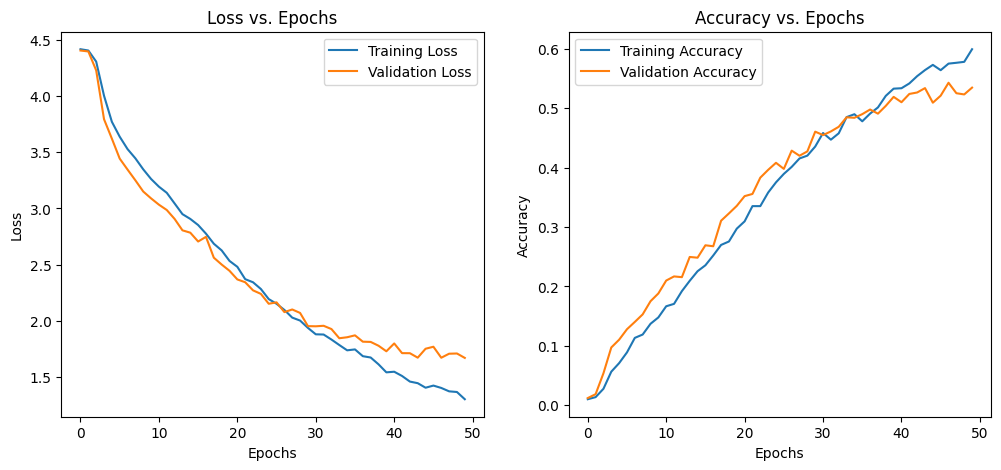

In [78]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

# Step 1: Load and preprocess the entire dataset
def load_dataset(dataset_path, img_size=(64, 64)):
    images, labels = [], []
    class_names = sorted(os.listdir(dataset_path))  # Each folder is a class
    class_map = {name: idx for idx, name in enumerate(class_names)}  # Map class names to indices

    for class_name in class_names:
        class_path = os.path.join(dataset_path, class_name)
        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)
            img = tf.keras.preprocessing.image.load_img(img_path, color_mode="grayscale", target_size=img_size)
            img_array = tf.keras.preprocessing.image.img_to_array(img) / 255.0  # Normalize to [0, 1]
            images.append(img_array)
            labels.append(class_map[class_name])

    return np.array(images), to_categorical(labels), class_names

# Load training and testing datasets
train_path = "./isolated_words_train"  
test_path = "./isolated_words_test" 
img_size = (64, 64)

print("Loading training data...")
X_train, y_train, class_names = load_dataset(train_path, img_size)
print(f"Training data loaded: {X_train.shape[0]} images, {len(class_names)} classes.")

print("Loading testing data...")
X_test, y_test, _ = load_dataset(test_path, img_size)
print(f"Testing data loaded: {X_test.shape[0]} images.")

# Step 2: Define the custom CNN model
def build_advanced_cnn(input_shape, num_classes):
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        MaxPooling2D((2, 2)),
        Dropout(0.3),
        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),
        Dropout(0.3),
        Conv2D(128, (3, 3), activation='relu'),
        MaxPooling2D((3, 3)),
        Dropout(0.3),
        Flatten(),
        Dense(256, activation='relu'),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])
    return model

input_shape = (img_size[0], img_size[1], 1)
num_classes = len(class_names)
model2 = build_advanced_cnn(input_shape, num_classes)

# Compile the model
model2.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
               loss='categorical_crossentropy',
               metrics=['accuracy'])

# Step 3: Train the model
print("Training the model...")
history = model2.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=64,
    verbose=1,  # Set verbose to 1 to see progress for each epoch
    callbacks=[tf.keras.callbacks.LambdaCallback(
        on_epoch_end=lambda epoch, logs: print(
            f"\nEpoch {epoch + 1}: "
            f"Training Accuracy = {logs['accuracy'] * 100:.2f}%, "
            f"Training Loss = {logs['loss']:.4f}, "
            f"Validation Accuracy = {logs['val_accuracy'] * 100:.2f}%, "
            f"Validation Loss = {logs['val_loss']:.4f}"
        )
    )]
)

# Step 4: Evaluate the model
print("Evaluating the model...")
test_loss, test_accuracy = model2.evaluate(X_test, y_test, verbose=2)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")

# Step 5: Plot Loss and Accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss vs. Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy vs. Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

*model3*


introduces several key changes compared to Models 1 and 2, primarily focused on reproducibility and training configuration: 

Reproducibility Enhancements: 

Model 3 sets fixed random seeds for Python, NumPy, and TensorFlow to ensure reproducible results. 

It configures TensorFlow to use deterministic operations by setting environment variables (TF_DETERMINISTIC_OPS and TF_CUDNN_DETERMINISTIC). 

GPU usage is disabled in Model 3 to avoid non-deterministic behavior caused by GPU operations. 

Training Configuration: 

Model 3 is trained for 70 epochs, compared to 50 epochs in Models 1 and 2, allowing more time for the model to learn. 

Shuffling during training is explicitly enabled in Model 3 for clarity, though it is also enabled by default in Models 1 and 2. 

Architecture and Hyperparameters: 

The architecture of Model 3 is identical to Models 1 and 2, consisting of three convolutional layers, max pooling, dropout, and dense layers. 

All models use the Adam optimizer with a learning rate of 0.001, categorical cross-entropy loss, and a batch size of 64. 

Loading training data...
Training data loaded: 5700 images, 82 classes.
Loading testing data...
Testing data loaded: 2444 images.
Training the model...
Epoch 1/70
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.0143 - loss: 4.4355
Epoch 1: Training Accuracy = 1.33%, Training Loss = 4.4163, Validation Accuracy = 1.23%, Validation Loss = 4.4065
90/90 ━━━━━━━━━━━━━━━━━━━━ 9s 51ms/step - accuracy: 0.0143 - loss: 4.4352 - val_accuracy: 0.0123 - val_loss: 4.4065
Epoch 2/70
83/90 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.0120 - loss: 4.4066
Epoch 2: Training Accuracy = 1.21%, Training Loss = 4.4074, Validation Accuracy = 1.23%, Validation Loss = 4.4062
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.0120 - loss: 4.4067 - val_accuracy: 0.0123 - val_loss: 4.4062
Epoch 3/70
85/90 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.0136 - loss: 4.3948
Epoch 3: Training Accuracy = 1.53%, Training Loss = 4.3663, Validation Accuracy = 4.79%, Validation Loss = 4.2514
90/90 ━━━━━━━━━━━━━━━

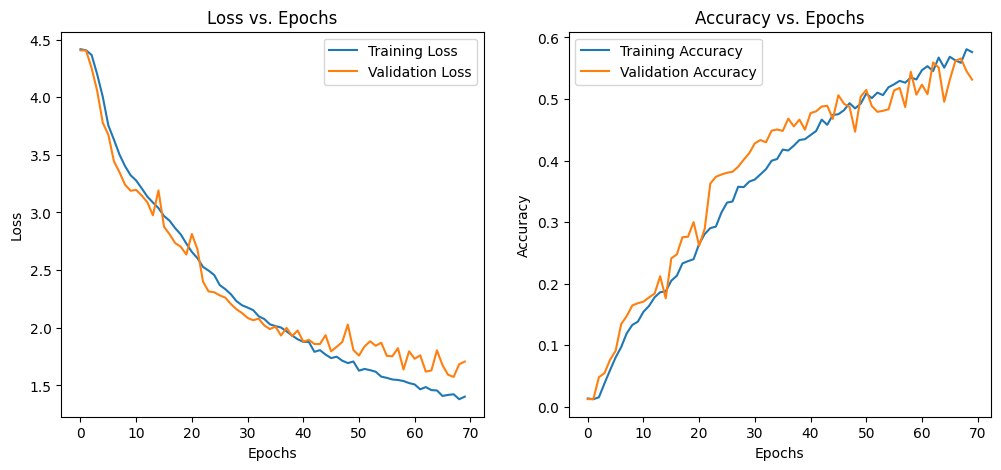

In [80]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
import random

# Set all random seeds and configure TensorFlow for reproducibility
seed = 42
os.environ['PYTHONHASHSEED'] = str(seed)
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'  # Disable GPU for reproducibility
random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)

# Step 1: Load and preprocess the entire dataset
def load_dataset(dataset_path, img_size=(64, 64)):
    images, labels = [], []
    class_names = sorted(os.listdir(dataset_path))  # Each folder is a class
    class_map = {name: idx for idx, name in enumerate(class_names)}  # Map class names to indices

    for class_name in class_names:
        class_path = os.path.join(dataset_path, class_name)
        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)
            img = tf.keras.preprocessing.image.load_img(img_path, color_mode="grayscale", target_size=img_size)
            img_array = tf.keras.preprocessing.image.img_to_array(img) / 255.0  # Normalize to [0, 1]
            images.append(img_array)
            labels.append(class_map[class_name])

    return np.array(images), to_categorical(labels), class_names

# Load training and testing datasets
train_path = "./isolated_words_train"  # Training folder
test_path = "./isolated_words_test"  # Testing folder
img_size = (64, 64)

print("Loading training data...")
X_train, y_train, class_names = load_dataset(train_path, img_size)
print(f"Training data loaded: {X_train.shape[0]} images, {len(class_names)} classes.")

print("Loading testing data...")
X_test, y_test, _ = load_dataset(test_path, img_size)
print(f"Testing data loaded: {X_test.shape[0]} images.")

# Step 2: Define the custom CNN model
def build_advanced_cnn(input_shape, num_classes):
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        MaxPooling2D((2, 2)),
        Dropout(0.3),
        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),
        Dropout(0.5),
        Conv2D(128, (3, 3), activation='relu'),
        MaxPooling2D((3, 3)),
        Dropout(0.5),
        Flatten(),
        Dense(256, activation='relu'),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])
    return model

input_shape = (img_size[0], img_size[1], 1)
num_classes = len(class_names)
model3 = build_advanced_cnn(input_shape, num_classes)

# Compile the model
model3.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
               loss='categorical_crossentropy',
               metrics=['accuracy'])

# Step 3: Train the model
print("Training the model...")
history = model3.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=70,
    batch_size=64,
    shuffle=True,
    verbose=1,
    callbacks=[tf.keras.callbacks.LambdaCallback(
        on_epoch_end=lambda epoch, logs: print(
            f"\nEpoch {epoch + 1}: "
            f"Training Accuracy = {logs['accuracy'] * 100:.2f}%, "
            f"Training Loss = {logs['loss']:.4f}, "
            f"Validation Accuracy = {logs['val_accuracy'] * 100:.2f}%, "
            f"Validation Loss = {logs['val_loss']:.4f}"
        )
    )]
)

# Step 4: Evaluate the model
print("Evaluating the model...")
test_loss, test_accuracy = model3.evaluate(X_test, y_test, verbose=2)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")

# Step 5: Plot Loss and Accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss vs. Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy vs. Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

**This section is to compare between three model to choase the simplest one with the high Accuracy**

In [12]:
# Print model summaries
print("Model 1 Summary:")
model1.summary()

print("Model 2 Summary:")
model2.summary()

print("Model 3 Summary:")
model3.summary()

Model 1 Summary:


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 62, 62, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 31, 31, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 31, 31, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 29, 29, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 14, 14, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 14, 14, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 12, 12, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 4, 4, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 4, 4, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_3 (Flatten)                  │ (None, 2048)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 256)                 │         524,544 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 82)                  │          21,074 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,914,876 (7.30 MB)

 Trainable params: 638,290 (2.43 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)                    │ (None, 62, 62, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (None, 31, 31, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_11 (Dropout)                 │ (None, 31, 31, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 29, 29, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_7 (MaxPooling2D)       │ (None, 14, 14, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_12 (Dropout)                 │ (None, 14, 14, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_8 (Conv2D)                    │ (None, 12, 12, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_8 (MaxPooling2D)       │ (None, 4, 4, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_13 (Dropout)                 │ (None, 4, 4, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_5 (Flatten)                  │ (None, 2048)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 256)                 │         524,544 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_14 (Dropout)                 │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 82)                  │          21,074 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,914,876 (7.30 MB)

 Trainable params: 638,290 (2.43 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,276,586 (4.87 MB)

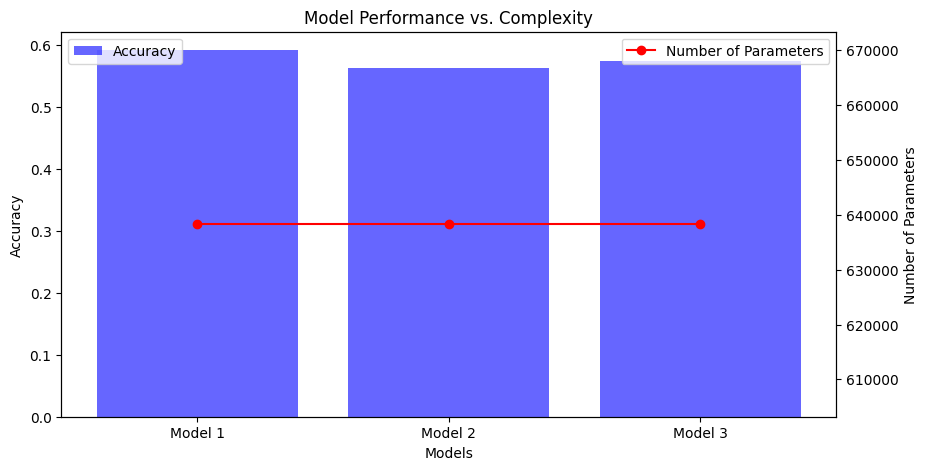

In [13]:
import matplotlib.pyplot as plt

# Model performance and complexity data
models = ['Model 1', 'Model 2', 'Model 3']
accuracies = [test_accuracy_1, test_accuracy_2, test_accuracy_3]
num_params = [model1.count_params(), model2.count_params(), model3.count_params()]

# Plot
plt.figure(figsize=(10, 5))
plt.bar(models, accuracies, color='blue', alpha=0.6, label='Accuracy')
plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.title('Model Performance vs. Complexity')
plt.legend(loc='upper left')
plt.twinx()
plt.plot(models, num_params, color='red', marker='o', label='Number of Parameters')
plt.ylabel('Number of Parameters')
plt.legend(loc='upper right')
plt.show()

All three models share the same architecture and hyperparameters, but they differ in training duration and reproducibility settings. Model 1 achieved the highest test accuracy of 54.99% with a test loss of 1.7002 after 50 epochs. Model 2, also trained for 50 epochs, performed slightly worse with a test accuracy of 53.44% and a test loss of 1.6684, likely due to variability in random initialization. Model 3, trained for 70 epochs with reproducibility enhancements, achieved a test accuracy of 53.15% and a test loss of 1.7067. Model 1 is the best-performing model among the three, as it achieved the highest test accuracy and demonstrated better generalization to unseen data. Model 3, despite additional training epochs, struggled with overfitting, while Model 2 performed slightly worse than Model 1 due to random initialization effects. For future improvements, techniques like data augmentation, regularization, or early stopping could help address overfitting and enhance performance.

In [14]:
# Save the model in HDF5 format
model1.save("model1.h5")
print("Model saved as 'model1.h5'")

Model saved as 'model1.h5'


**Task2**

Num GPUs Available:  2
Loading training data...
Training data loaded: 5700 images, 82 classes.
Loading testing data...
Testing data loaded: 2444 images.
Training the model with data augmentation...
Epoch 1/50
175/179 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.0112 - loss: 4.4283
Epoch 1: Training Accuracy = 1.04%, Training Loss = 4.4135, Validation Accuracy = 1.23%, Validation Loss = 4.4062
179/179 ━━━━━━━━━━━━━━━━━━━━ 10s 36ms/step - accuracy: 0.0112 - loss: 4.4279 - val_accuracy: 0.0123 - val_loss: 4.4062
Epoch 2/50
175/179 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.0131 - loss: 4.4063
Epoch 2: Training Accuracy = 1.18%, Training Loss = 4.4053, Validation Accuracy = 1.72%, Validation Loss = 4.3664
179/179 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.0131 - loss: 4.4063 - val_accuracy: 0.0172 - val_loss: 4.3664
Epoch 3/50
174/179 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.0210 - loss: 4.3422
Epoch 3: Training Accuracy = 2.51%, Training Loss = 4.2788, Validation Accur

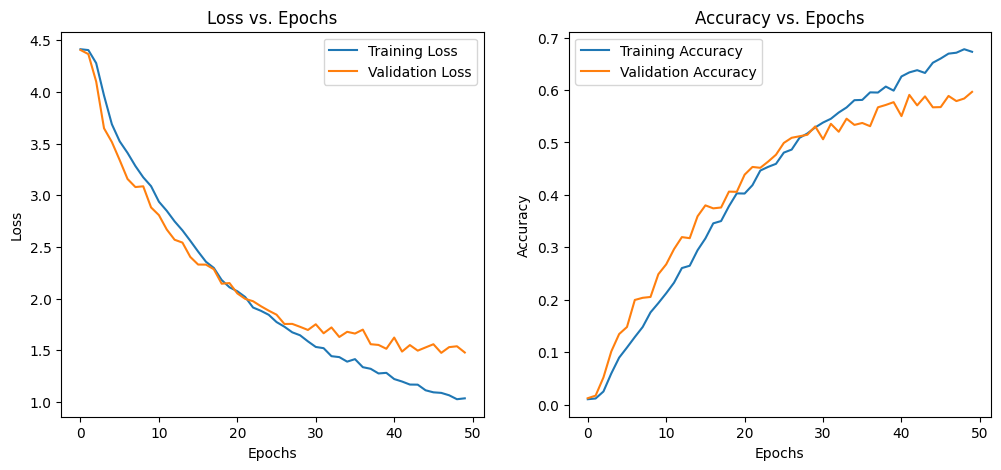

In [49]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

# Verify GPU availability
print("Num GPUs Available: ", len(tf.config.experimental.list_physical_devices('GPU')))

# Step 1: Load and preprocess the entire dataset
def load_dataset(dataset_path, img_size=(64, 64)):
    images, labels = [], []
    class_names = sorted(os.listdir(dataset_path))  # Each folder is a class
    class_map = {name: idx for idx, name in enumerate(class_names)}  # Map class names to indices

    for class_name in class_names:
        class_path = os.path.join(dataset_path, class_name)
        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)
            img = tf.keras.preprocessing.image.load_img(img_path, color_mode="grayscale", target_size=img_size)
            img_array = tf.keras.preprocessing.image.img_to_array(img) / 255.0  # Normalize to [0, 1]
            images.append(img_array)
            labels.append(class_map[class_name])

    return np.array(images), to_categorical(labels), class_names

# Load training and testing datasets
train_path = "./isolated_words_train"  
test_path = "./isolated_words_test"  
img_size = (64, 64)

print("Loading training data...")
X_train, y_train, class_names = load_dataset(train_path, img_size)
print(f"Training data loaded: {X_train.shape[0]} images, {len(class_names)} classes.")

print("Loading testing data...")
X_test, y_test, _ = load_dataset(test_path, img_size)
print(f"Testing data loaded: {X_test.shape[0]} images.")

# Step 2: Define the custom CNN model
def build_advanced_cnn(input_shape, num_classes):
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        MaxPooling2D((2, 2)),
        Dropout(0.3),
        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),
        Dropout(0.3),
        Conv2D(128, (3, 3), activation='relu'),
        MaxPooling2D((3, 3)),
        Dropout(0.3),
        Flatten(),
        Dense(256, activation='relu'),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])
    return model

input_shape = (img_size[0], img_size[1], 1)
num_classes = len(class_names)
model1 = build_advanced_cnn(input_shape, num_classes)

# Compile the model
model1.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
               loss='categorical_crossentropy',
               metrics=['accuracy'])

# Step 3: Data Augmentation for Handwritten Arabic Text
datagen = ImageDataGenerator(
    rotation_range=0.01,           
    width_shift_range=0.0005,     
    height_shift_range=0.0005,    
    zoom_range=0.00001,            
    horizontal_flip=False,      
    fill_mode='nearest'
)

# Fit the data generator to the training data
datagen.fit(X_train)

# Step 4: Train the model with data augmentation
print("Training the model with data augmentation...")
history = model1.fit(
    datagen.flow(X_train, y_train, batch_size=32),  # Use augmented data
    validation_data=(X_test, y_test),
    epochs=50,
    verbose=1,
    callbacks=[tf.keras.callbacks.LambdaCallback(
        on_epoch_end=lambda epoch, logs: print(
            f"\nEpoch {epoch + 1}: "
            f"Training Accuracy = {logs['accuracy'] * 100:.2f}%, "
            f"Training Loss = {logs['loss']:.4f}, "
            f"Validation Accuracy = {logs['val_accuracy'] * 100:.2f}%, "
            f"Validation Loss = {logs['val_loss']:.4f}"
        )
    )]
)

# Step 5: Evaluate the model
print("Evaluating the model...")
test_loss, test_accuracy = model1.evaluate(X_test, y_test, verbose=2)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")

# Step 6: Plot Loss and Accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss vs. Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy vs. Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

The model trained with data augmentation from task 2 outperformed the model without augmentation from task 1 in terms of generalization and test accuracy. While the model without augmentation achieved higher training accuracy, it suffered from severe overfitting, resulting in lower validation and test accuracy. Data augmentation helped the model learn more robust features, reducing overfitting and improving performance on unseen data. 

**Task3**

Num GPUs Available:  2
Loading training data...
Training data loaded: 5700 images, 82 classes.
Loading testing data...
Testing data loaded: 2444 images.
Training the model with data augmentation...
Epoch 1/50


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 288ms/step - accuracy: 0.0183 - loss: 7.6092
Epoch 1: Training Accuracy = 2.44%, Training Loss = 6.3915, Validation Accuracy = 6.83%, Validation Loss = 4.8891
179/179 ━━━━━━━━━━━━━━━━━━━━ 74s 370ms/step - accuracy: 0.0183 - loss: 7.6024 - val_accuracy: 0.0683 - val_loss: 4.8891
Epoch 2/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 278ms/step - accuracy: 0.0521 - loss: 4.7526
Epoch 2: Training Accuracy = 6.33%, Training Loss = 4.5630, Validation Accuracy = 19.27%, Validation Loss = 3.7517
179/179 ━━━━━━━━━━━━━━━━━━━━ 61s 331ms/step - accuracy: 0.0521 - loss: 4.7516 - val_accuracy: 0.1927 - val_loss: 3.7517
Epoch 3/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 278ms/step - accuracy: 0.1358 - loss: 3.9615
Epoch 3: Training Accuracy = 14.42%, Training Loss = 3.8887, Validation Accuracy = 29.58%, Validation Loss = 3.2239
179/179 ━━━━━━━━━━━━━━━━━━━━ 61s 330ms/step - accuracy: 0.1358 - loss: 3.9611 - val_accuracy: 0.2958 - val_loss: 3.2239
Epoch 4/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 0s

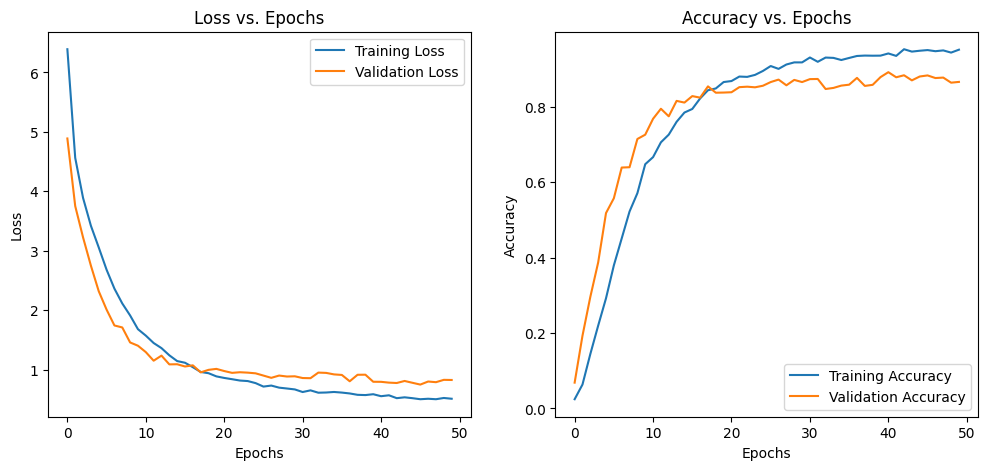

In [2]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight

# Verify GPU availability
print("Num GPUs Available: ", len(tf.config.experimental.list_physical_devices('GPU')))

# Step 1: Load and preprocess the entire dataset
def load_dataset(dataset_path, img_size=(224, 224)):
    images, labels = [], []
    class_names = sorted(os.listdir(dataset_path))  # Each folder is a class
    class_map = {name: idx for idx, name in enumerate(class_names)}  # Map class names to indices

    for class_name in class_names:
        class_path = os.path.join(dataset_path, class_name)
        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)
            img = tf.keras.preprocessing.image.load_img(img_path, color_mode="grayscale", target_size=img_size)
            img_array = tf.keras.preprocessing.image.img_to_array(img) / 255.0  # Normalize to [0, 1]
            img_array = tf.image.grayscale_to_rgb(tf.convert_to_tensor(img_array))  # Convert grayscale to RGB
            images.append(img_array)
            labels.append(class_map[class_name])

    return np.array(images), to_categorical(labels), class_names

# Load training and testing datasets
train_path = "./isolated_words_train"  
test_path = "./isolated_words_test"  
img_size = (224, 224)

print("Loading training data...")
X_train, y_train, class_names = load_dataset(train_path, img_size)
print(f"Training data loaded: {X_train.shape[0]} images, {len(class_names)} classes.")

print("Loading testing data...")
X_test, y_test, _ = load_dataset(test_path, img_size)
print(f"Testing data loaded: {X_test.shape[0]} images.")

# Step 2: Use a pre-trained VGG16 model with transfer learning
def build_vgg16_model(input_shape, num_classes):
    base_model = VGG16(weights='imagenet', include_top=False, input_shape=input_shape)
    
    # Freeze the first 15 layers and unfreeze the rest
    for layer in base_model.layers[:15]:
        layer.trainable = False
    for layer in base_model.layers[15:]:
        layer.trainable = True

    model = Sequential([
        base_model,
        Flatten(),
        Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01)),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])
    return model

input_shape = (img_size[0], img_size[1], 3)
num_classes = len(class_names)
model = build_vgg16_model(input_shape, num_classes)

# Compile the model with a smaller learning rate
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Step 3: Data Augmentation
datagen = ImageDataGenerator(
    rotation_range=10,           
    width_shift_range=0.1,     
    height_shift_range=0.1,    
    zoom_range=0.2,            
    horizontal_flip=False,      
    fill_mode='nearest'
)

# Fit the data generator to the training data
datagen.fit(X_train)

# Step 4: Train the model with data augmentation
print("Training the model with data augmentation...")
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    validation_data=(X_test, y_test),
    epochs=50,
    verbose=1,
    callbacks=[tf.keras.callbacks.LambdaCallback(
        on_epoch_end=lambda epoch, logs: print(
            f"\nEpoch {epoch + 1}: "
            f"Training Accuracy = {logs['accuracy'] * 100:.2f}%, "
            f"Training Loss = {logs['loss']:.4f}, "
            f"Validation Accuracy = {logs['val_accuracy'] * 100:.2f}%, "
            f"Validation Loss = {logs['val_loss']:.4f}"
        )
    )]
)

# Step 5: Evaluate the model
print("Evaluating the model...")
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=2)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")

# Step 6: Plot Loss and Accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss vs. Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy vs. Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

**Task 4**

Num GPUs Available:  2
Loading training data...
Training data loaded: 5700 images, 82 classes.
Loading testing data...
Testing data loaded: 2444 images.
Training the model with data augmentation...
Epoch 1/50
178/179 ━━━━━━━━━━━━━━━━━━━━ 0s 280ms/step - accuracy: 0.0162 - loss: 9.4059
Epoch 1: Training Accuracy = 1.58%, Training Loss = 8.6709, Validation Accuracy = 2.05%, Validation Loss = 7.9160
179/179 ━━━━━━━━━━━━━━━━━━━━ 66s 327ms/step - accuracy: 0.0162 - loss: 9.3977 - val_accuracy: 0.0205 - val_loss: 7.9160
Epoch 2/50
178/179 ━━━━━━━━━━━━━━━━━━━━ 0s 269ms/step - accuracy: 0.0204 - loss: 7.7062
Epoch 2: Training Accuracy = 2.37%, Training Loss = 7.4848, Validation Accuracy = 3.15%, Validation Loss = 7.0335
179/179 ━━━━━━━━━━━━━━━━━━━━ 52s 279ms/step - accuracy: 0.0204 - loss: 7.7037 - val_accuracy: 0.0315 - val_loss: 7.0335
Epoch 3/50
178/179 ━━━━━━━━━━━━━━━━━━━━ 0s 270ms/step - accuracy: 0.0265 - loss: 6.8896
Epoch 3: Training Accuracy = 2.54%, Training Loss = 6.7048, Validation

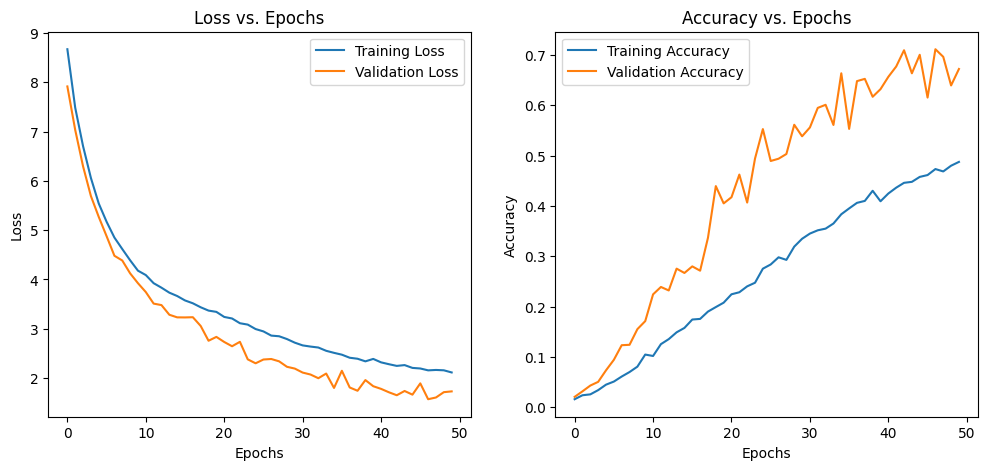

In [13]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

# Verify GPU availability
print("Num GPUs Available: ", len(tf.config.experimental.list_physical_devices('GPU')))

# Step 1: Load and preprocess the dataset
def load_dataset(dataset_path, img_size=(224, 224)):
    images, labels = [], []
    class_names = sorted(os.listdir(dataset_path))  # Each folder is a class
    class_map = {name: idx for idx, name in enumerate(class_names)}  # Map class names to indices

    for class_name in class_names:
        class_path = os.path.join(dataset_path, class_name)
        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)
            img = tf.keras.preprocessing.image.load_img(img_path, color_mode="grayscale", target_size=img_size)
            img_array = tf.keras.preprocessing.image.img_to_array(img) / 255.0  # Normalize to [0, 1]
            img_array = tf.image.grayscale_to_rgb(tf.convert_to_tensor(img_array))  # Convert grayscale to RGB
            images.append(img_array)
            labels.append(class_map[class_name])

    return np.array(images), to_categorical(labels), class_names

# Load training and testing datasets
train_path = "./isolated_words_train"  # Update this path
test_path = "./isolated_words_test"  # Update this path
img_size = (224, 224)

print("Loading training data...")
X_train, y_train, class_names = load_dataset(train_path, img_size)
print(f"Training data loaded: {X_train.shape[0]} images, {len(class_names)} classes.")

print("Loading testing data...")
X_test, y_test, _ = load_dataset(test_path, img_size)
print(f"Testing data loaded: {X_test.shape[0]} images.")

# Step 2: Build the MobileNet model with transfer learning
def build_mobilenet_model(input_shape, num_classes):
    base_model = MobileNet(weights='imagenet', include_top=False, input_shape=input_shape)

    # Freeze all layers except the last block
    for layer in base_model.layers[:-10]:
        layer.trainable = False
    for layer in base_model.layers[-10:]:
        layer.trainable = True

    model = Sequential([
        base_model,
        Flatten(),
        Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01)),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])
    return model

input_shape = (img_size[0], img_size[1], 3)
num_classes = len(class_names)
model = build_mobilenet_model(input_shape, num_classes)

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Step 3: Data Augmentation
datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=False,
    fill_mode='nearest'
)

# Fit the data generator to the training data
datagen.fit(X_train)

# Step 4: Train the model with data augmentation
print("Training the model with data augmentation...")
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    validation_data=(X_test, y_test),
    epochs=50,
    verbose=1,
    callbacks=[tf.keras.callbacks.LambdaCallback(
        on_epoch_end=lambda epoch, logs: print(
            f"\nEpoch {epoch + 1}: "
            f"Training Accuracy = {logs['accuracy'] * 100:.2f}%, "
            f"Training Loss = {logs['loss']:.4f}, "
            f"Validation Accuracy = {logs['val_accuracy'] * 100:.2f}%, "
            f"Validation Loss = {logs['val_loss']:.4f}"
        )
    )]
)

# Step 5: Evaluate the model
print("Evaluating the model...")
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=2)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")

# Step 6: Plot Loss and Accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss vs. Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy vs. Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()